<a href="https://colab.research.google.com/github/Kishanmvs/Machine-Learning-II-Lab-BCI702/blob/main/Lab2_SupervisedLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Supervised Learning Pipeline — Water Potability Dataset

**Prerequisite (Foundational)** — evaluation metrics reused in Experiments 6, 9 & 10.

This notebook covers:
1. Loading the dataset (via `kagglehub`)
2. Basic cleaning (handling missing values)
3. Train–test split
4. Training a simple classifier (scikit-learn)
5. Evaluation — accuracy, precision, recall, F1-score, confusion matrix


## 1. Imports

In [1]:
import kagglehub
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_columns', 50)

RANDOM_STATE = 42


## 2. Download and Load the Dataset

In [2]:
# Download latest version of the dataset from Kaggle
path = kagglehub.dataset_download("developerghost/water-potability")
print("Path to dataset files:", path)

# List files in the downloaded folder
files = os.listdir(path)
print("Files found:", files)


100%|██████████| 2.22M/2.22M [00:00<00:00, 73.8MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/developerghost/water-potability/versions/1
Files found: ['Watera.csv']


In [3]:
# Load the first CSV file found in the dataset folder
csv_files = [f for f in files if f.endswith('.csv')]
print("CSV files:", csv_files)

file_path = os.path.join(path, csv_files[0])
df = pd.read_csv(file_path)

print("Shape:", df.shape)
df.head()


CSV files: ['Watera.csv']
Shape: (100000, 10)


,ph,hardness,tds,chlorine,sulfate,conductivity,organic_carbon,trihalomethanes,turbidity,potability
0,7.14,440.98,614.26,2.12,208.39,350.92,7.22,17.32,2.23,0
1,6.41,242.82,387.89,3.93,313.10,153.36,9.92,20.69,2.07,0
2,6.29,133.09,225.55,1.46,332.04,1420.43,8.76,32.87,5.05,0
3,7.39,71.89,459.23,0.56,609.63,24142.89,9.62,42.80,2.26,0
4,6.31,273.01,308.99,0.64,52.59,196.85,1.05,133.38,5.30,0


## 3. Quick Data Overview

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   ph               96879 non-null   float64
 1   hardness         100000 non-null  float64
 2   tds              97616 non-null   float64
 3   chlorine         100000 non-null  float64
 4   sulfate          99187 non-null   float64
 5   conductivity     98402 non-null   float64
 6   organic_carbon   100000 non-null  float64
 7   trihalomethanes  100000 non-null  float64
 8   turbidity        100000 non-null  float64
 9   potability       100000 non-null  int64  
dtypes: float64(9), int64(1)
memory usage: 7.6 MB


In [5]:
print("Missing values per column:\n")
print(df.isnull().sum())


Missing values per column:

ph                 3121
hardness              0
tds                2384
chlorine              0
sulfate             813
conductivity       1598
organic_carbon        0
trihalomethanes       0
turbidity             0
potability            0
dtype: int64


## 4. Identify Target Column

The Water Potability dataset uses `Potability` (0 = not potable, 1 = potable) as the target.
The cell below falls back to the last column if the expected name isn't found, so this
notebook keeps working even if column naming differs slightly.


In [6]:
target_col = 'Potability' if 'Potability' in df.columns else df.columns[-1]
print("Target column:", target_col)

df[target_col].value_counts()


Target column: potability


,count
potability,
0,92384
1,7616


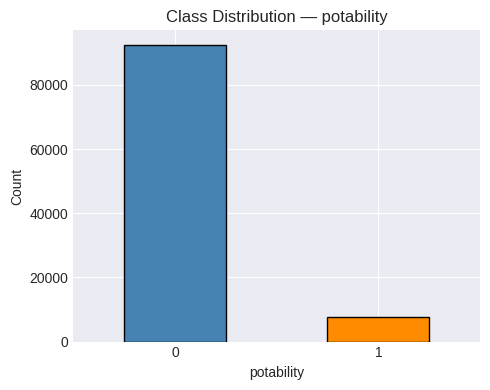

In [7]:
plt.figure(figsize=(5, 4))
df[target_col].value_counts().plot(kind='bar', color=['steelblue', 'darkorange'], edgecolor='black')
plt.title(f"Class Distribution — {target_col}")
plt.xlabel(target_col)
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 5. Handle Missing Values

In [8]:
# Impute missing numeric values with the column median (fit only on training data later
# to avoid leakage, but for simplicity here we impute globally with medians computed
# from the full feature set before splitting — a common, simple baseline approach)
feature_cols = [c for c in df.columns if c != target_col]

for col in feature_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

print("Remaining missing values:", df.isnull().sum().sum())


Remaining missing values: 0


## 6. Train–Test Split

In [9]:
X = df[feature_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (80000, 9)
Test shape: (20000, 9)


## 7. Feature Scaling

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 8. Train a Simple Classifier

In [11]:
# Random Forest is a strong, easy-to-use baseline classifier
clf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
clf.fit(X_train_scaled, y_train)

y_pred = clf.predict(X_test_scaled)


## 9. Evaluation Metrics

In [12]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")


Accuracy:  0.9974
Precision: 0.9688
Recall:    0.9987
F1-score:  0.9835


In [13]:
print("Full classification report:\n")
print(classification_report(y_test, y_pred))


Full classification report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18477
           1       0.97      1.00      0.98      1523

    accuracy                           1.00     20000
   macro avg       0.98      1.00      0.99     20000
weighted avg       1.00      1.00      1.00     20000



## 10. Confusion Matrix

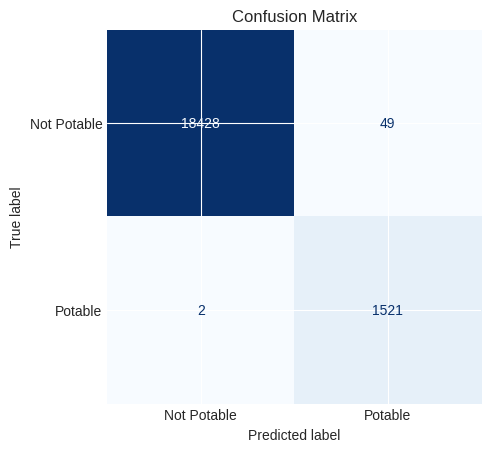

In [14]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Potable', 'Potable'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


## 11. Feature Importance (bonus)

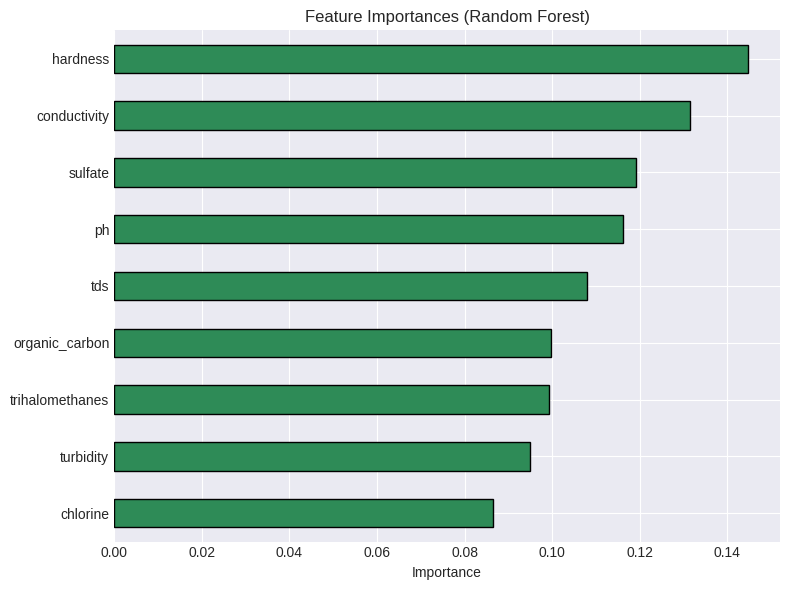

In [15]:
importances = pd.Series(clf.feature_importances_, index=feature_cols).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
importances.plot(kind='barh', color='seagreen', edgecolor='black')
plt.title("Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


## 12. Conclusion

- Loaded the Water Potability dataset directly from Kaggle using `kagglehub`.
- Handled missing values via median imputation.
- Split the data into training and test sets (80/20, stratified on the target).
- Scaled features and trained a `RandomForestClassifier` as a simple baseline model.
- Evaluated the model using **accuracy, precision, recall, F1-score**, and a **confusion matrix**.
- Inspected feature importances to understand which water-quality measurements matter most.

This evaluation workflow (train–test split → fit → accuracy/precision/recall/F1/confusion matrix) is the
foundational pattern reused in later experiments (Expts. 6, 9 & 10).
